In [1]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root[len("/kaggle/input"):].count(os.sep)
    if depth <= 3:
        print(root, "-> dirs:", dirs[:5], f"| files: {len(files)}")
    if depth > 3:
        break

/kaggle/input -> dirs: ['notebooks'] | files: 0
/kaggle/input/notebooks -> dirs: ['vidhushinikg'] | files: 0
/kaggle/input/notebooks/vidhushinikg -> dirs: ['hybrid-model', 'age-prediction-preprocessing'] | files: 0
/kaggle/input/notebooks/vidhushinikg/hybrid-model -> dirs: [] | files: 7
/kaggle/input/notebooks/vidhushinikg/age-prediction-preprocessing -> dirs: ['__results___files', 'processed_faces_10_80'] | files: 5


In [2]:
import os
hybrid_dir = "/kaggle/input/notebooks/vidhushinikg/hybrid-model"
for f in os.listdir(hybrid_dir):
    full_path = os.path.join(hybrid_dir, f)
    size_mb = os.path.getsize(full_path) / (1024*1024) if os.path.isfile(full_path) else 0
    print(f"{f} — {size_mb:.1f} MB")

__results__.html — 0.4 MB
__huggingface_repos__.json — 0.0 MB
hybrid_age_model.pt — 200.7 MB
hybrid_age_model.onnx — 202.9 MB
__notebook__.ipynb — 0.1 MB
__output__.json — 1.9 MB
custom.css — 0.0 MB


In [3]:
!pip install -q --no-deps facenet-pytorch
!pip install -q dlib onnxruntime

import cv2
import dlib
import numpy as np
import torch
import pandas as pd
import os
from PIL import Image
from facenet_pytorch import MTCNN
import onnxruntime as ort

ONNX_PATH = "/kaggle/input/notebooks/vidhushinikg/hybrid-model/hybrid_age_model.onnx"
DATA_DIR = "/kaggle/input/notebooks/vidhushinikg/age-prediction-preprocessing/processed_faces_10_80"

device = "cuda" if torch.cuda.is_available() else "cpu"
mtcnn_detector = MTCNN(keep_all=False, select_largest=True, post_process=False, device=device)

if not os.path.exists("/kaggle/working/shape_predictor.dat"):
    !wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 -O /kaggle/working/shape_predictor.dat.bz2
    !bzip2 -d /kaggle/working/shape_predictor.dat.bz2

dlib_predictor = dlib.shape_predictor("/kaggle/working/shape_predictor.dat")
print("Detection + alignment ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 76.5 MB/s eta 0:00:00:00:0100:01
Detection + alignment ready.


In [4]:
MIN_AGE, MAX_AGE = 10, 80
NUM_CLASSES = MAX_AGE - MIN_AGE + 1

LEFT_EYE_IDX, RIGHT_EYE_IDX = list(range(36,42)), list(range(42,48))
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

def get_eye_centers(landmarks):
    left = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in LEFT_EYE_IDX])
    right = np.array([(landmarks.part(i).x, landmarks.part(i).y) for i in RIGHT_EYE_IDX])
    return left.mean(axis=0), right.mean(axis=0)

def align_and_crop(image_bgr, box, target_size=224):
    x1,y1,x2,y2 = [int(v) for v in box]
    h,w = image_bgr.shape[:2]
    x1,y1,x2,y2 = max(0,x1), max(0,y1), min(w,x2), min(h,y2)
    landmarks = dlib_predictor(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), dlib.rectangle(x1,y1,x2,y2))
    left_eye, right_eye = get_eye_centers(landmarks)
    angle = np.degrees(np.arctan2(right_eye[1]-left_eye[1], right_eye[0]-left_eye[0]))
    eyes_center = ((left_eye[0]+right_eye[0])/2, (left_eye[1]+right_eye[1])/2)
    rot_mat = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)
    rotated = cv2.warpAffine(image_bgr, rot_mat, (w,h), flags=cv2.INTER_CUBIC)
    mx, my = int((x2-x1)*0.2), int((y2-y1)*0.2)
    cx1,cy1,cx2,cy2 = max(0,x1-mx), max(0,y1-my), min(w,x2+mx), min(h,y2+my)
    crop = rotated[cy1:cy2, cx1:cx2]
    if crop.size == 0: return None
    return cv2.resize(crop, (target_size,target_size), interpolation=cv2.INTER_AREA)

def apply_clahe(face_bgr):
    lab = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge((l,a,b)), cv2.COLOR_LAB2BGR)


def predict_age_from_image(image_path, onnx_session, confidence_level=0.90, show_image=True):
    pil_img = Image.open(image_path).convert("RGB")
    image_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    boxes, _ = mtcnn_detector.detect(pil_img)
    if boxes is None or len(boxes) == 0:
        print("No face detected in this image.")
        return None

    aligned = align_and_crop(image_bgr, boxes[0])
    if aligned is None:
        print("Face detected but crop failed.")
        return None

    final_face = apply_clahe(aligned)

    face_rgb = cv2.cvtColor(final_face, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    face_norm = (face_rgb - MEAN) / STD
    input_tensor = face_norm.transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32)

    logits = onnx_session.run(None, {"image": input_tensor})[0][0]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()

    classes = np.arange(NUM_CLASSES)
    pred_class = (probs * classes).sum()
    variance = (probs * (classes - pred_class) ** 2).sum()
    std_dev = np.sqrt(variance)
    pred_age = pred_class + MIN_AGE

    from scipy.stats import norm as scipy_norm
    z = scipy_norm.ppf(0.5 + confidence_level / 2)
    lower = pred_age - z * std_dev
    upper = pred_age + z * std_dev

    print(f"Predicted age: {pred_age:.1f} years")
    print(f"{confidence_level:.0%} confidence range: {lower:.1f} - {upper:.1f} years")

    if show_image:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(8,4))
        axes[0].imshow(pil_img)
        axes[0].set_title("Original")
        axes[0].axis("off")
        axes[1].imshow(cv2.cvtColor(final_face, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Age: {pred_age:.1f} ± {z*std_dev:.1f}")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

    return pred_age, (lower, upper)

print("Inference function ready.")

Inference function ready.


ONNX model loaded.
Actual age: 17
Predicted age: 33.6 years
90% confidence range: 5.8 - 61.3 years


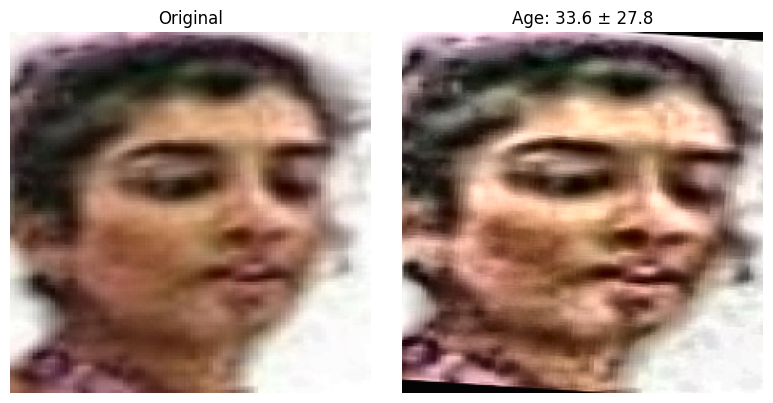

(np.float64(33.55327226733789),
 (np.float64(5.774493165382513), np.float64(61.33205136929327)))

In [5]:
onnx_session = ort.InferenceSession(ONNX_PATH)
print("ONNX model loaded.")

test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_row = test_df.iloc[0]
sample_path = os.path.join(DATA_DIR, sample_row["filename"])
print(f"Actual age: {sample_row['age']}")

predict_age_from_image(sample_path, onnx_session)

In [6]:
def predict_from_preprocessed(image_path, onnx_session, confidence_level=0.90):
    """For images that are ALREADY through the preprocessing pipeline (from processed_faces_10_80)."""
    face_bgr = cv2.imread(image_path)
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    face_norm = (face_rgb - MEAN) / STD
    input_tensor = face_norm.transpose(2, 0, 1)[np.newaxis, ...].astype(np.float32)

    logits = onnx_session.run(None, {"image": input_tensor})[0][0]
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()

    classes = np.arange(NUM_CLASSES)
    pred_class = (probs * classes).sum()
    variance = (probs * (classes - pred_class) ** 2).sum()
    std_dev = np.sqrt(variance)
    pred_age = pred_class + MIN_AGE

    from scipy.stats import norm as scipy_norm
    z = scipy_norm.ppf(0.5 + confidence_level / 2)
    lower, upper = pred_age - z*std_dev, pred_age + z*std_dev

    print(f"Predicted age: {pred_age:.1f} years")
    print(f"{confidence_level:.0%} confidence range: {lower:.1f} - {upper:.1f} years")
    return pred_age, (lower, upper)


# retest on the SAME image, correctly this time
print(f"Actual age: {sample_row['age']}")
predict_from_preprocessed(sample_path, onnx_session)

Actual age: 17
Predicted age: 21.4 years
90% confidence range: 8.0 - 34.8 years


(np.float64(21.39991043737973),
 (np.float64(8.031086289806394), np.float64(34.768734584953066)))

In [7]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

Predicted age: 58.7 years
90% confidence range: 41.9 - 75.6 years


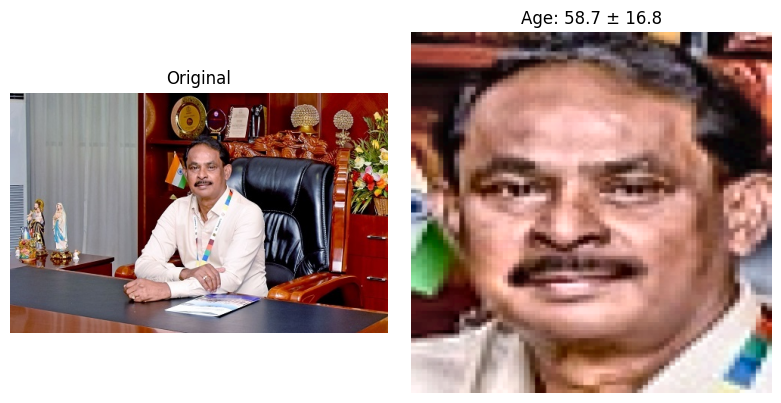

(np.float64(58.74639192284667),
 (np.float64(41.92730465197366), np.float64(75.56547919371968)))

In [12]:
uploaded_file = uploader.value[0]  # tuple, not dict -- index directly instead of .values()
with open("/kaggle/working/uploaded_photo.jpg", "wb") as f:
    f.write(uploaded_file['content'])

predict_age_from_image("/kaggle/working/uploaded_photo.jpg", onnx_session)

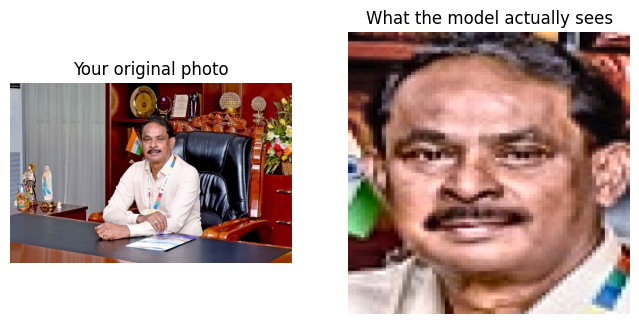

In [13]:
face_bgr = cv2.imread("/kaggle/working/uploaded_photo.jpg")
pil_img = Image.open("/kaggle/working/uploaded_photo.jpg").convert("RGB")
image_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

boxes, _ = mtcnn_detector.detect(pil_img)
aligned = align_and_crop(image_bgr, boxes[0])
final_face = apply_clahe(aligned)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(pil_img)
axes[0].set_title("Your original photo")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(final_face, cv2.COLOR_BGR2RGB))
axes[1].set_title("What the model actually sees")
axes[1].axis("off")
plt.show()